In [ ]:
#Scikit-learn : Python's standard ML Library(pre installed in Collab)

from sklearn.model_selection import train_test_split
#train_test_split : divides data into training and testing portions

from sklearn.preprocessing import LabelEncoder, StandardScaler
#Label Encoder : converts text categories to integers(Male=0;Female=0)
#StandardScaler: scales numbers so all features have some range

from sklearn.linear_model import LinearRegression
#LinearRegression : fills a straight line relationship between features and target

from sklearn.tree import DecisionTreeRegressor
#DecisionTreeRegressor : builds a tree of if/else rules to predict

from sklearn.ensemble import RandomForestRegressor
#RandomForestRegressor : build 100 decision trees and averages predictions

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
#mean_squared_error : average absolute prediction error
#mean_squared_error : average squared error

In [ ]:
import pandas as pd
# STEP 2 : Load the student dataset
df=pd.read_csv('student_performance (1).csv')
print(f'Dataset loaded:{df.shape[0]} students, {df.shape[1]} columns')
print(f'columns:{df.columns.tolist()}')
print(f'Missing values:{df.isnull().sum().sum()}')
print(f'\nFirst 5 rows:')
df.head()

Dataset loaded:30 students, 13 columns
columns:['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']
Missing values:0

First 5 rows:


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023


In [ ]:
print(df['programming_score'].describe())

count    30.000000
mean     67.600000
std      21.041175
min      38.000000
25%      49.250000
50%      66.000000
75%      88.750000
max      97.000000
Name: programming_score, dtype: float64


In [ ]:
#STEP 4 : Feature Engineering: Encode categorical columns

df_ml = df.copy()

# Encode 'gender' column
le_gender = LabelEncoder()
df_ml['gender_encoded'] = le_gender.fit_transform(df_ml['gender'])
print(f'Gender encoding : {dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_)))}\n')

# Encode 'department' column
le_dept = LabelEncoder()
df_ml['department_encoded'] = le_dept.fit_transform(df_ml['department']) # Corrected from 'dept' to 'department'
print(f'Department encoding : {dict(zip(le_dept.classes_, le_dept.transform(le_dept.classes_)))}\n') # Corrected variable names

print('\nNew columns added: gender_encoded, department_encoded')
df_ml[['gender', 'gender_encoded', 'department', 'department_encoded']].head(5)

Gender encoding : {'Female': np.int64(0), 'Male': np.int64(1)}

Department encoding : {'Civil': np.int64(0), 'Computer Science': np.int64(1), 'Electronics': np.int64(2), 'Mechanical': np.int64(3)}


New columns added: gender_encoded, department_encoded


,gender,gender_encoded,department,department_encoded
0,Male,1,Computer Science,1
1,Female,0,Computer Science,1
2,Male,1,Electronics,2
3,Female,0,Mechanical,3
4,Male,1,Computer Science,1


In [ ]:
#Step 4 : Feature Enginerring : Encode  categorical columns

df_ml = df.copy()
le_gender = LabelEncoder()
df_ml['gender_encoded'] = le_gender.fit_transform(df_ml['gender'])
print(f'Gender encoding : {dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_)))}\n')

le_dept = LabelEncoder()
df_ml['department_encoded'] = le_dept.fit_transform(df_ml['department'])
print(f'Department encoding : {dict(zip(le_dept.classes_, le_dept.transform(le_dept.classes_)))}\n')

print('\nNew columns added: gender_encoded, department_encoded')
df_ml[['gender', 'gender_encoded', 'department', 'department_encoded']].head(5)



Gender encoding : {'Female': np.int64(0), 'Male': np.int64(1)}

Department encoding : {'Civil': np.int64(0), 'Computer Science': np.int64(1), 'Electronics': np.int64(2), 'Mechanical': np.int64(3)}


New columns added: gender_encoded, department_encoded


,gender,gender_encoded,department,department_encoded
0,Male,1,Computer Science,1
1,Female,0,Computer Science,1
2,Male,1,Electronics,2
3,Female,0,Mechanical,3
4,Male,1,Computer Science,1


In [ ]:
# STEP 5 : Define features and target

feature_cols = [
    'math_score',
    'science_score', # Added science_score as a feature
    'english_score', # Added english_score as a feature
    'gender_encoded',
    'department_encoded'
]

target_col = 'programming_score'

x = df_ml[feature_cols]
y = df_ml[target_col]

print(f'Features matrix X shape : {x.shape}')
print(f'Target vector y shape : {y.shape}')
print(f'Feature columns: \n{feature_cols}')
print(f'Target column: {target_col}')
print(f'Target range : {y.min()} to {y.max()}')

Features matrix X shape : (30, 5)
Target vector y shape : (30,)
Feature columns: 
['math_score', 'science_score', 'english_score', 'gender_encoded', 'department_encoded']
Target column: programming_score
Target range : 38 to 97


In [ ]:
# STEP 6 : Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    x, y, # Corrected X,Y to x,y
    test_size = 0.2,
    random_state = 42 # Corrected randomn_state to random_state
  )

print(f'Total students : {len(x)}') # Corrected X to x
print(f'Training data : {len(X_train)}')
print(f'Testing data : {len(X_test)}')
print(f'Training target : {len(y_train)}-{y_train.max()}')
print(f'Testing target : {len(y_test)}') # Added closing parenthesis and quote

Total students : 30
Training data : 24
Testing data : 6
Training target : 24-96
Testing target : 6


In [ ]:
# STEP 7 : Scale Features with StandardScaler

scaler = StandardScaler()
# StandardScaler transforms each feature to have mean=0 and std=1
# Formula: scaled_value = (original_value - mean) / standard_deviation
# Example: math_score of 85 with mean=76 and std=10 → (85-76)/10 = 0.9

X_train_scaled = scaler.fit_transform(X_train)
# fit_transform on TRAINING data:
#   fit:       calculates mean and std FROM TRAINING DATA ONLY
#   transform: applies the scaling
# CRITICAL: we fit ONLY on training data — the model must not 'see' test data

X_test_scaled = scaler.transform(X_test)
# transform ONLY on test data (not fit_transform!)
# We use the SAME mean and std learned from training data
# This simulates real deployment: new data is scaled using training statistics

print('Features scaled successfully!')
print(f'Training feature mean (should be ≈0): {X_train_scaled.mean():.4f}')
print(f'Training feature std  (should be ≈1): {X_train_scaled.std():.4f}')
print('\nNote: Scaler was fit on training data only — prevents data leakage')



Features scaled successfully!
Training feature mean (should be ≈0): 0.0000
Training feature std  (should be ≈1): 1.0000

Note: Scaler was fit on training data only — prevents data leakage


In [ ]:
import numpy as np

#Train Model 1: Linear Regression
lr_model = LinearRegression()
# LinearRegression() creates an UNTRAINED model
# At this point the model is like a blank student who has read no examples

lr_model.fit(X_train_scaled, y_train)
# .fit() is the TRAINING step
# The model processes all 24 training students
# It finds the best weights (coefficients) w1, w2, ... w6
# that minimise prediction error
# Formula learned: programming_score ≈ w1*math + w2*science + ... + bias

lr_pred = lr_model.predict(X_test_scaled)
# .predict() applies learned weights to the 6 TEST students
# Returns predicted programming scores
# The model has NEVER seen these 6 students during training

# Evaluate
lr_mae  = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2   = r2_score(y_test, lr_pred)

print('=== Model 1: Linear Regression ===')
print(f'MAE  : {lr_mae:.2f}  (predictions are off by {lr_mae:.1f} points on average)')
print(f'RMSE : {lr_rmse:.2f}  (error with penalty for large mistakes)')
print(f'R²   : {lr_r2:.4f}  ({lr_r2*100:.1f}% of programming score variation explained)')
print()
print('Learned coefficients (importance of each feature):')
for feat, coef in zip(feature_cols, lr_model.coef_):
    print(f'  {feat:<28}: {coef:+.3f}')
# Positive coefficient = higher value → higher predicted score
# Negative coefficient = higher value → lower predicted score
# Larger absolute value = more influence on prediction
print(f'  {"bias (intercept)":<28}: {lr_model.intercept_:.3f}')

=== Model 1: Linear Regression ===
MAE  : 5.35  (predictions are off by 5.4 points on average)
RMSE : 7.48  (error with penalty for large mistakes)
R²   : 0.8874  (88.7% of programming score variation explained)

Learned coefficients (importance of each feature):
  math_score                  : +11.066
  science_score               : +6.158
  english_score               : +1.734
  gender_encoded              : +2.549
  department_encoded          : -2.519
  bias (intercept)            : 68.042


In [ ]:
#Train Model 2: Decision Tree
dt_model = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)
# DecisionTreeRegressor builds a tree of if/else rules:
#   IF math_score > 80 AND attendance > 88 THEN score ≈ 91
#   IF math_score <= 80 THEN score ≈ 65
# max_depth=5: limit tree to 5 levels
#   Without this limit, the tree grows until it memorizes every training
#   student perfectly (overfitting) but fails on new data
# random_state=42: reproducible results

dt_model.fit(X_train_scaled, y_train)
dt_pred = dt_model.predict(X_test_scaled)

dt_mae  = mean_absolute_error(y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_r2   = r2_score(y_test, dt_pred)

print('=== Model 2: Decision Tree (max_depth=5) ===')
print(f'MAE  : {dt_mae:.2f}')
print(f'RMSE : {dt_rmse:.2f}')
print(f'R²   : {dt_r2:.4f}')

=== Model 2: Decision Tree (max_depth=5) ===
MAE  : 9.08
RMSE : 13.07
R²   : 0.6565


In [ ]:
#Train Model 3: Random Forest
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
# RandomForestRegressor builds MANY decision trees and averages predictions
# n_estimators=100: build 100 different Decision Trees
#   Each tree is trained on a random SUBSET of training students
#   Each tree uses a random SUBSET of features at each split
# Final prediction = average of all 100 tree predictions
# Why better than one tree?
#   Each tree makes different errors. Averaging cancels out random errors.
#   This is called ensemble learning — wisdom of the crowd applied to ML

rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)

rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2   = r2_score(y_test, rf_pred)

print('=== Model 3: Random Forest (100 trees) ===')
print(f'MAE  : {rf_mae:.2f}')
print(f'RMSE : {rf_rmse:.2f}')
print(f'R²   : {rf_r2:.4f}')

=== Model 3: Random Forest (100 trees) ===
MAE  : 9.99
RMSE : 13.77
R²   : 0.6191


In [ ]:
#Compare all three models side by side
print('=' * 60)
print('  MODEL COMPARISON')
print('=' * 60)
print(f'{"Model":<20} {"MAE":>8} {"RMSE":>8} {"R²":>8}')
print('-' * 48)

results = [
    ('Linear Regression', lr_mae, lr_rmse, lr_r2),
    ('Decision Tree',     dt_mae, dt_rmse, dt_r2),
    ('Random Forest',     rf_mae, rf_rmse, rf_r2),
]

best_model = None
best_r2 = -999

for name, mae, rmse, r2 in results:
    star = ' ← BEST' if r2 == max(lr_r2, dt_r2, rf_r2) else ''
    print(f'{name:<20} {mae:>8.2f} {rmse:>8.2f} {r2:>8.4f}{star}')
    if r2 > best_r2:
        best_r2 = r2
        best_model = name

print('=' * 60)
print(f'Best model: {best_model} (R² = {best_r2:.4f})')
print()
print('Interpretation:')
print(f'  MAE = {min(lr_mae,dt_mae,rf_mae):.1f} means predictions are off by ~{min(lr_mae,dt_mae,rf_mae):.0f} marks on average')
print(f'  R² = {best_r2:.2f} means {best_r2*100:.0f}% of score variation is explained by our features')

  MODEL COMPARISON
Model                     MAE     RMSE       R²
------------------------------------------------
Linear Regression        5.35     7.48   0.8874 ← BEST
Decision Tree            9.08    13.07   0.6565
Random Forest            9.99    13.77   0.6191
Best model: Linear Regression (R² = 0.8874)

Interpretation:
  MAE = 5.4 means predictions are off by ~5 marks on average
  R² = 0.89 means 89% of score variation is explained by our features


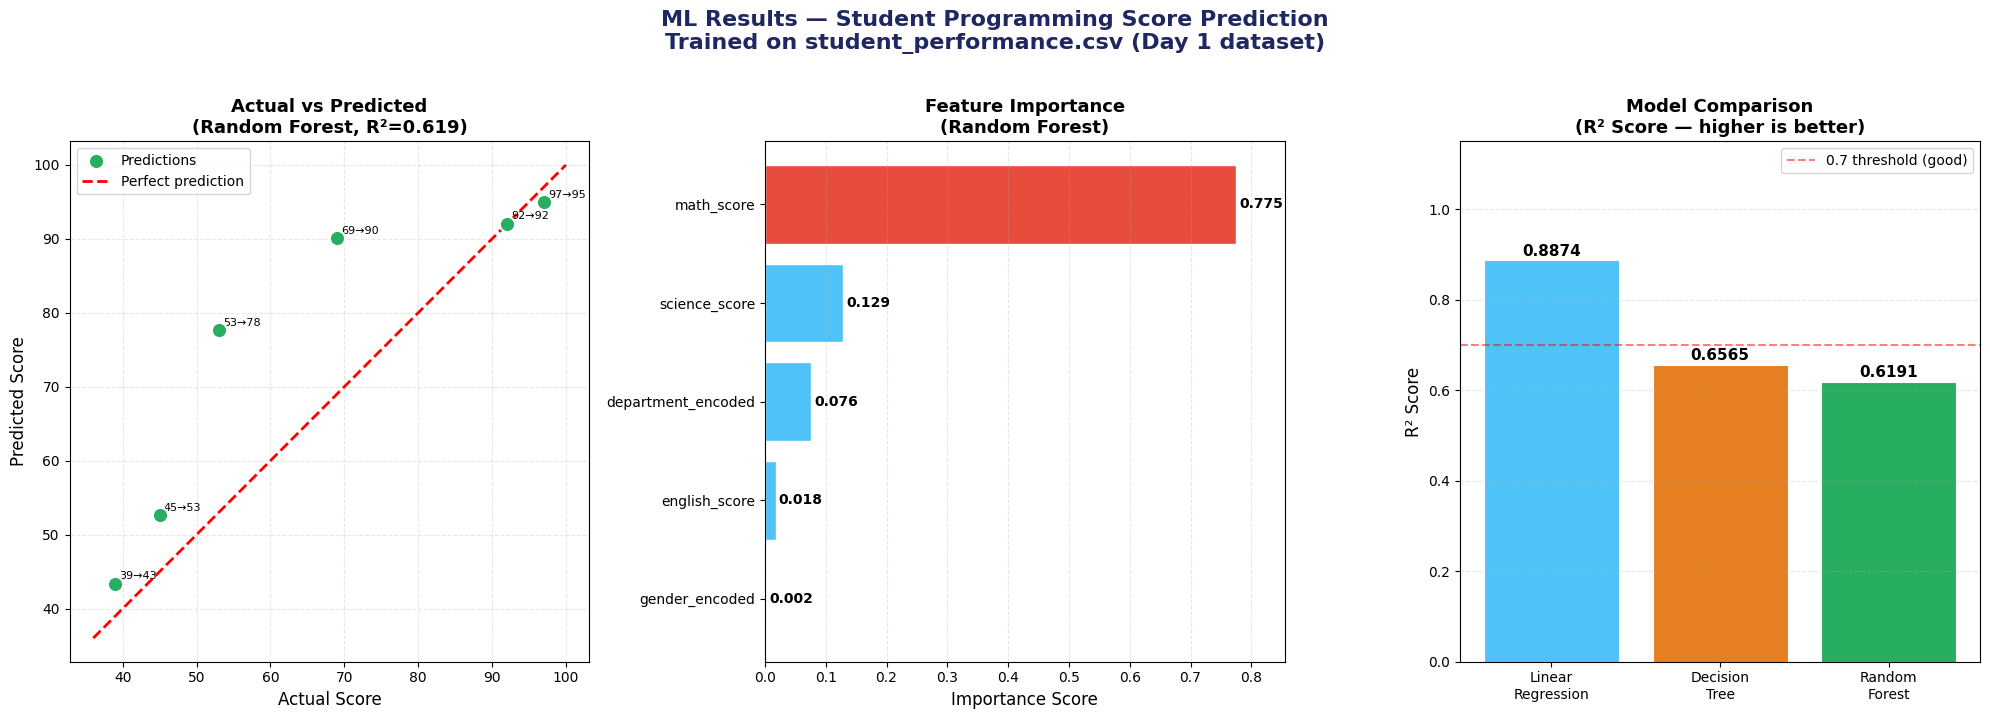

Dashboard saved: ml_results_dashboard.png


In [ ]:
import matplotlib.pyplot as plt

#Visualization: 3-panel ML results dashboard
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle(
    'ML Results — Student Programming Score Prediction\n'
    'Trained on student_performance.csv (Day 1 dataset)',
    fontsize=16, fontweight='bold', color='#1E2761', y=1.02
)

# ── Panel 1: Actual vs Predicted (Random Forest) ──
ax1 = axes[0]
ax1.scatter(y_test, rf_pred, color='#27AE60', s=120, zorder=5,
            edgecolors='white', linewidth=1.5, label='Predictions')
# scatter plot: x = actual scores, y = predicted scores
# Perfect model = all points on the diagonal line

min_val = min(y_test.min(), rf_pred.min()) - 3
max_val = max(y_test.max(), rf_pred.max()) + 3
ax1.plot([min_val, max_val], [min_val, max_val],
         'r--', linewidth=2, label='Perfect prediction')
# Diagonal line = where actual == predicted
# Points close to line = good predictions

for i, (actual, pred) in enumerate(zip(y_test, rf_pred)):
    ax1.annotate(f'{actual}→{pred:.0f}',
                 (actual, pred), fontsize=8, ha='left',
                 xytext=(3, 3), textcoords='offset points')

ax1.set_xlabel('Actual Score', fontsize=12)
ax1.set_ylabel('Predicted Score', fontsize=12)
ax1.set_title(f'Actual vs Predicted\n(Random Forest, R²={rf_r2:.3f})',
              fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3, linestyle='--')

# ── Panel 2: Feature Importance (Random Forest) ──
ax2 = axes[1]
importances = rf_model.feature_importances_
# feature_importances_: how much each feature contributed to predictions
# Values sum to 1.0 (100%)
# Higher = more important for the model's decisions

feat_imp_df = pd.DataFrame({'feature': feature_cols, 'importance': importances})
feat_imp_df = feat_imp_df.sort_values('importance', ascending=True)

colors = ['#E74C3C' if i > 0.15 else '#4FC3F7'
          for i in feat_imp_df['importance']]
bars = ax2.barh(feat_imp_df['feature'], feat_imp_df['importance'],
                color=colors, edgecolor='white')
for bar in bars:
    ax2.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.3f}',
             va='center', fontsize=10, fontweight='bold')
ax2.set_title('Feature Importance\n(Random Forest)',
              fontsize=13, fontweight='bold')
ax2.set_xlabel('Importance Score', fontsize=12)
ax2.grid(axis='x', alpha=0.3, linestyle='--')
ax2.set_xlim(0, max(importances) + 0.08)

# ── Panel 3: Model Comparison Bar Chart ──
ax3 = axes[2]
model_names = ['Linear\nRegression', 'Decision\nTree', 'Random\nForest']
r2_scores   = [lr_r2, dt_r2, rf_r2]
bar_colors  = ['#4FC3F7', '#E67E22', '#27AE60']

bars3 = ax3.bar(model_names, r2_scores,
                color=bar_colors, edgecolor='white', linewidth=0.8)
for bar, score in zip(bars3, r2_scores):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{score:.4f}', ha='center', fontsize=11, fontweight='bold')
ax3.set_title('Model Comparison\n(R² Score — higher is better)',
              fontsize=13, fontweight='bold')
ax3.set_ylabel('R² Score', fontsize=12)
ax3.set_ylim(0, 1.15)
ax3.axhline(y=0.7, color='red', linestyle='--', alpha=0.5, label='0.7 threshold (good)')
ax3.legend(fontsize=10)
ax3.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('ml_results_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard saved: ml_results_dashboard.png')

In [ ]:
#Predict programming score for new hypothetical students
# Define new students (not in our dataset)
new_students = pd.DataFrame({
    'math_score':            [88,  62,  75],
    'science_score':         [82,  58,  80],
    'english_score':         [75,  65,  72],
    'attendance_percentage': [92,  70,  85],
    'gender_encoded':        [1,   0,   1 ],   # 1=Male, 0=Female
    'department_encoded':    [1,   2,   0 ],   # 1=CS, 2=Electronics, 0=Civil
})
# These are completely hypothetical students
# The model was never trained on these — truly new predictions

# Scale using the SAME scaler fitted on training data
new_students_scaled = scaler.transform(new_students[feature_cols])
# We must use .transform() (not .fit_transform())
# The scaler already learned the mean and std from training data
# We just apply those same statistics to new data

# Predict with all three models
predictions_lr = lr_model.predict(new_students_scaled)
predictions_dt = dt_model.predict(new_students_scaled)
predictions_rf = rf_model.predict(new_students_scaled)

print('=== PREDICTIONS FOR NEW STUDENTS ===')
print(f'{"":<12} {"Math":>6} {"Sci":>5} {"Eng":>5} {"Att%":>6} | {"Lin.Reg":>8} {"Dec.Tree":>9} {"Rand.Forest":>12}')
print('-' * 72)

student_labels = ['Student A', 'Student B', 'Student C']
for i, label in enumerate(student_labels):
    row = new_students.iloc[i]
    print(f'{label:<12} {row["math_score"]:>6} {row["science_score"]:>5} '
          f'{row["english_score"]:>5} {row["attendance_percentage"]:>6} | '
          f'{predictions_lr[i]:>8.1f} {predictions_dt[i]:>9.1f} {predictions_rf[i]:>12.1f}')

print()
print('Interpretation:')
print('  Student A (high scores + attendance) → predicted to score well')
print('  Student B (lower scores + attendance) → predicted to score lower')
print('  Student C (mixed profile) → mid-range prediction')
print()
print('The model learned these patterns from 24 training students!')

=== PREDICTIONS FOR NEW STUDENTS ===
               Math   Sci   Eng   Att% |  Lin.Reg  Dec.Tree  Rand.Forest
------------------------------------------------------------------------
Student A        88    82    75     92 |     88.0      93.0         89.8
Student B        62    58    65     70 |     33.3      55.0         57.3
Student C        75    80    72     85 |     75.0      40.0         59.5

Interpretation:
  Student A (high scores + attendance) → predicted to score well
  Student B (lower scores + attendance) → predicted to score lower
  Student C (mixed profile) → mid-range prediction

The model learned these patterns from 24 training students!


In [ ]:
#Predict for a student using YOUR OWN scores

YOUR_MATH       = 80
YOUR_SCIENCE    = 75
YOUR_ENGLISH    = 70
YOUR_ATTENDANCE = 88
YOUR_GENDER     = 1
YOUR_DEPT       = 1

# Create a DataFrame with a single row for the new student, using feature_cols
my_data_df = pd.DataFrame([[YOUR_MATH, YOUR_SCIENCE, YOUR_ENGLISH,
                            YOUR_GENDER, YOUR_DEPT]], columns=feature_cols)

my_data = scaler.transform(my_data_df)

my_prediction = rf_model.predict(my_data)[0]
# rf_model.predict() returns an array — [0] gets the single value

print(f'Your input: Math={YOUR_MATH}, Science={YOUR_SCIENCE}, '
      f'English={YOUR_ENGLISH}, Attendance={YOUR_ATTENDANCE}%')
print(f'\nPredicted Programming Score: {my_prediction:.1f}')
print(f'(Random Forest model, R²={rf_r2:.3f})')

Your input: Math=80, Science=75, English=70, Attendance=88%

Predicted Programming Score: 77.0
(Random Forest model, R²=0.619)
